In [1]:
# will need to remove part of this later

%load_ext autoreload
%autoreload 2
import sys 
sys.path.insert(0,'.')

In [2]:
from qiskit import IBMQ
from qiskit.providers.fake_provider import FakeBrooklyn, FakeManila, FakeMontreal

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from qiskit import (ClassicalRegister, QuantumCircuit, QuantumRegister,
                    quantum_info, transpile)
from qiskit.circuit.gate import Gate
from qiskit.circuit.quantumregister import QuantumRegister
from qiskit.ignis.mitigation.measurement import (CompleteMeasFitter,
                                                 TensoredMeasFitter,
                                                 complete_meas_cal,
                                                 tensored_meas_cal)
from qiskit.ignis.mitigation.measurement.filters import (MeasurementFilter,
                                                         TensoredFilter)
from qiskit.ignis.verification.tomography import (StateTomographyFitter,
                                                  state_tomography_circuits)


In [5]:
def partial_counts(counts, start) :
    p_counts = {}
    for key, val in counts.items():
        new_key = partial_key(key, start)
        if new_key not in p_counts:
            p_counts[new_key] = 0
        p_counts[new_key] += val
    return p_counts


def partial_key(key: str, start):
    key = key[::-1]

    return key[start:start + 2][::-1]


def refill_key(key: str, start, length):

    key = key[::-1]
    refilled_key = ['a'] * length
    refilled_key[start] = key[0]
    refilled_key[start + 1] = key[1]

    return ''.join(refilled_key[::-1])


def same_circuit_mitigate(
    result,
    init_layout,
    mitigation_method='tensored',
    res_idx=0,
    state_labels=None,
    nonP: int = 1
): 
    num_qubits = len(init_layout)

    if mitigation_method == 'tensored':
        mit_pattern = [[qb] for qb in range(num_qubits)]
        meas_fitter = TensoredMeasFitter(
            result,
            mit_pattern=mit_pattern,  # type:ignore
            circlabel='mcal')
    elif mitigation_method == 'complete':
        mit_pattern = list(range(num_qubits))
        meas_fitter = CompleteMeasFitter(result, state_labels=state_labels)
    elif mitigation_method == 'bell1':

        odd_list = [[2 * i + 1, (2 * i + 2) % len(init_layout)]
                    for i in range(len(init_layout) // 2)]

        meas_fitter = TensoredMeasFitter(result,
                                         mit_pattern=odd_list,
                                         circlabel='mcalodd')

        filter = meas_fitter.filter
        counts_dict = {}
        raw_counts = result.get_counts(res_idx)
        for ii, qubit_pair in enumerate(odd_list):
            partial_filter = MeasurementFilter(
                meas_fitter.cal_matrices[ii],  #type:ignore
                ['00', '01', '10', '11'
                ])
            partial_count_dict = partial_filter.apply(
                partial_counts(raw_counts, ii * 2))
            for key, val in partial_count_dict.items():  #type:ignore
                new_key = refill_key(key, ii * 2, len(init_layout))
                new_key_orderded = new_key[1:] + new_key[0]
                counts_dict[
                    new_key_orderded] = val  
        return counts_dict, (meas_fitter, filter)  # type:ignore
    elif mitigation_method == 'bell0':
        even_list = [[2 * i, (2 * i + 1) % len(init_layout)]
                     for i in range(len(init_layout) // 2)]

        meas_fitter = TensoredMeasFitter(result,
                                         mit_pattern=even_list,
                                         circlabel='mcaleven')
        filter = meas_fitter.filter
        counts_dict = {}
        raw_counts = result.get_counts(res_idx)
        for ii, qubit_pair in enumerate(even_list):
            partial_filter = MeasurementFilter(
                meas_fitter.cal_matrices[ii],  #type:ignore
                ['00', '01', '10', '11'
                ])
            partial_count_dict = partial_filter.apply(
                partial_counts(raw_counts, ii * 2))
            for key, val in partial_count_dict.items():  #type:ignore
                new_key = refill_key(key, ii * 2, len(init_layout))
                counts_dict[
                    new_key] = val  
        return counts_dict, (meas_fitter, filter)  # type:ignore
    else:
        mit_pattern = list(range(num_qubits))
        meas_fitter = CompleteMeasFitter(result, state_labels=state_labels)
        meas_fitter.cal_matrix = np.array(np.eye(2**len(init_layout)))
    filter = meas_fitter.filter  # type:ignore

    return filter.apply(result), (meas_fitter, filter)  # type:ignore
 

def bell_meas_calc(result ,
                   init_layout,
                   mitigation_method='zprep',
                   exp_rep=1,
                   state_labels=None,
                   nonP=1,
                   delta=1,intercept=False):

    energies = [[0, 0]] * exp_rep
    for exp_idx in range(exp_rep):
        if mitigation_method in ['zprep', 'bellprep']:
            count_dict0, _ = same_circuit_mitigate(result,
                                                   init_layout,
                                                   mitigation_method='bell0',
                                                   res_idx=2 * exp_idx + 0,
                                                   state_labels=state_labels[0])
            count_dict1, _ = same_circuit_mitigate(result,
                                                   init_layout,
                                                   mitigation_method='bell1',
                                                   res_idx=2 * exp_idx + 1,
                                                   state_labels=state_labels[1])
        elif mitigation_method == 'none':
            count_dict0 = result.get_counts(2 * exp_idx)
            new_count_dict1 = {}
            count_dict1 = result.get_counts(2 * exp_idx + 1)
            for key, val in count_dict1.items():
                new_count_dict1[key[1:] + key[0]] = val
            count_dict1 = new_count_dict1
        else:
            print('Currently not supported method')
            return 1000

        if intercept:
            return count_dict0, count_dict1



In [6]:
#energy calculation using results of Bell measurement; see main text
def energy_calc(key_dict,delta, shots=8192):
    
    sub_e = 0 
    for akey,val in key_dict.items():
        # assume total shot is 8192
        if akey == '11':
            sub_e += (-2 - delta) *val/shots
        elif akey == '10':
            sub_e += (2 - delta) * val / shots
        elif akey == '00':
            sub_e += delta * val / shots
        elif akey == '01':
            sub_e += delta * val / shots
        else:
            pass
    return sub_e

In [8]:
from pathlib import Path
from qiskit.result import Result
import json
def dejsonfy_job(job_id: str):
    full_path = str(Path(f'./{job_id}.json').resolve())
    if Path(full_path).exists():
        with open(full_path, 'r') as file:
            result_dict = json.load(file)
            result = Result.from_dict(result_dict)
            return result

    print('Result not yet cached.')
    return None


In [9]:
bell_result = dejsonfy_job('629d414722557ec70f649842-output')

In [10]:
from qiskit.visualization import plot_histogram

In [11]:
# return raw data before processing
delta=0.8
exp_rep=5
rep_list=[0,1,2,3,4]
miti_method2 = 'bellprep'
init_layout = [15,12,13,14,16,19,22,25]
bell_state_labels = [[[1, 2], [3, 4],[5,6],[7,0]], [[0, 1], [2, 3],[4,5],[6,7]]]
bell_raw0,bell_raw1= bell_meas_calc(bell_result,
                               init_layout=init_layout,
                               mitigation_method='none',
                               exp_rep=exp_rep * 2 * len(rep_list),
                               state_labels=bell_state_labels,
                               delta=delta,intercept=True)
bell_miti0,bell_miti1 = bell_meas_calc(bell_result,
                               init_layout=init_layout,
                               mitigation_method=miti_method2,
                               exp_rep=exp_rep * 2 * len(rep_list),
                               state_labels=bell_state_labels,
                               delta=delta,intercept=True)

In [12]:
# output mitigated bitstring explicitly
# create container for even / odd layers of 01qubit, 23qubit, and 12qubit
bell_miti0_01 ={'00':0,'01':0,'10':0,'11':0}
bell_miti0_23 = {'00':0,'01':0,'10':0,'11':0}
bell_miti0_45 = {'00':0,'01':0,'10':0,'11':0}
bell_miti0_67 = {'00':0,'01':0,'10':0,'11':0}
bell_miti1_12 = {'00':0,'01':0,'10':0,'11':0}
bell_miti1_34 = {'00':0,'01':0,'10':0,'11':0}
bell_miti1_56 = {'00':0,'01':0,'10':0,'11':0}
for key in bell_miti0_01.keys():
    bell_miti0_01[key] = bell_miti0['aa'*3+key]
    bell_miti0_23[key] = bell_miti0['aa'*2+key+'aa']
    bell_miti0_45[key] = bell_miti0['aa'+key+'aa'*2]
    bell_miti0_67[key] = bell_miti0[key+'aa'*3]
    bell_miti1_12[key] = bell_miti1['a'*5+key+'a']
    bell_miti1_34[key] = bell_miti1['a'*3+key+'a'*3]
    bell_miti1_56[key] = bell_miti1['a'*1+key+'a'*5]


In [13]:
# output raw results bitstring explicitly
# create container for even / odd layers of 01qubit, 23qubit, and 12qubit
bell_raw0_01 = {'00':0,'01':0,'10':0,'11':0}
bell_raw0_23 = {'00':0,'01':0,'10':0,'11':0}
bell_raw0_45 = {'00':0,'01':0,'10':0,'11':0}
bell_raw0_67 = {'00':0,'01':0,'10':0,'11':0}
bell_raw1_12 = {'00':0,'01':0,'10':0,'11':0}
bell_raw1_34 = {'00':0,'01':0,'10':0,'11':0}
bell_raw1_56 = {'00':0,'01':0,'10':0,'11':0}
for key,val in bell_raw0.items():
    bell_raw0_01[key[0:2]] += val 
    bell_raw0_23[key[2:4]] += val
    bell_raw0_45[key[4:6]] += val
    bell_raw0_67[key[6:8]] += val
    bell_raw1_12[key[1:3]] += val
    bell_raw1_34[key[3:5]] += val
    bell_raw1_56[key[5:7]] += val

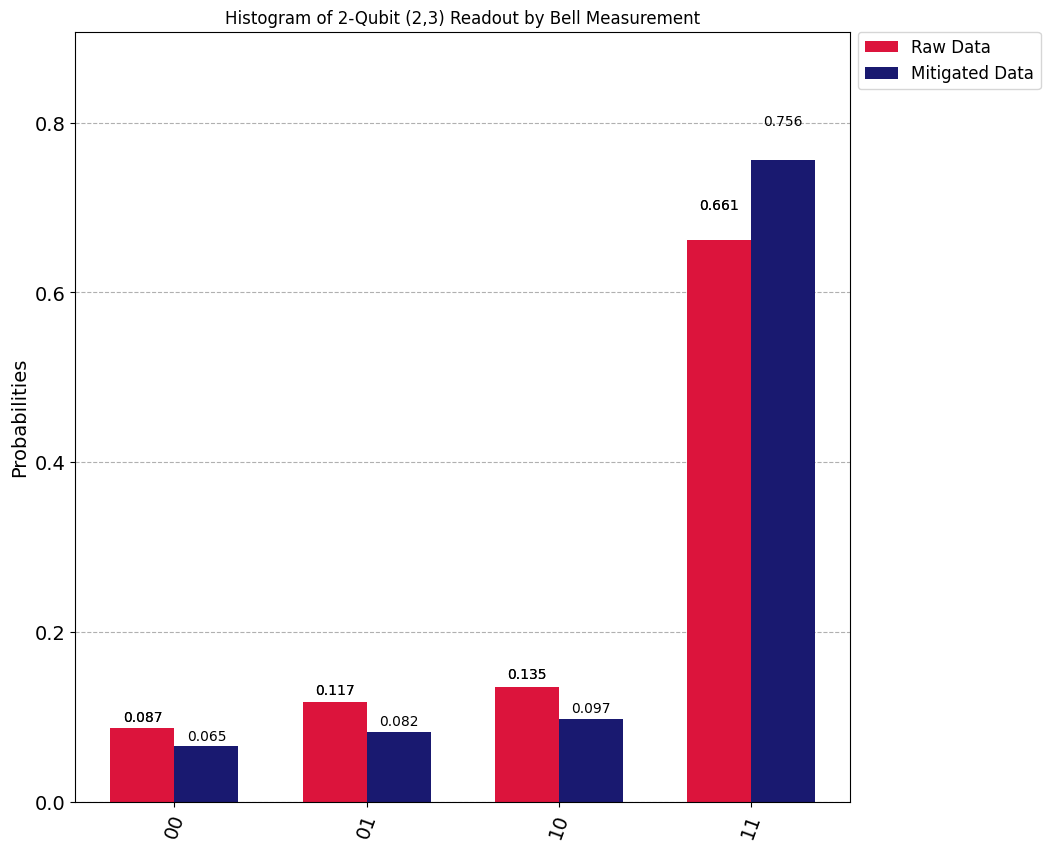

In [14]:
# data = [bell_raw0_01,bell_miti0_01]
data = [bell_raw0_23,bell_miti0_23]
# data = [bell_raw1_12,bell_miti1_12]
legend = ['Raw Data', 'Mitigated Data']
title = 'Histogram of 2-Qubit (2,3) Readout by Bell Measurement'
figsize = (10,10)
color=['crimson','midnightblue']
plot_histogram(data, legend=legend, title=title, figsize=figsize, color=color)
# The 11 state corresponds to the singlet state

In [22]:
energy_calc(bell_miti0_01,delta,shots=32000) + energy_calc(bell_miti0_23,delta,shots=32000) + energy_calc(bell_miti0_45,delta,shots=32000)+energy_calc(bell_miti0_67,delta,shots=32000) + energy_calc(bell_miti1_12,delta,shots=32000) + energy_calc(bell_miti1_34,delta,shots=32000)+ energy_calc(bell_miti1_56,delta,shots=32000)
#calculate the mitigated energy

-9.54803110745674

In [21]:
energy_calc(bell_raw0_01,delta,shots=32000) + energy_calc(bell_raw0_23,delta,shots=32000) + energy_calc(bell_raw0_45,delta,shots=32000)+energy_calc(bell_raw0_67,delta,shots=32000) + energy_calc(bell_raw1_12,delta,shots=32000) + energy_calc(bell_raw1_34,delta,shots=32000)+ energy_calc(bell_raw1_56,delta,shots=32000)
#calculate the raw energy

-11.132475

In [ ]:
#exact ansatz energy should be -12.427405
#exact ground state energy should be -12.619006

In [23]:
import qiskit
qiskit.__qiskit_version__

{'qiskit-terra': '0.21.2', 'qiskit-aer': '0.11.0', 'qiskit-ignis': '0.7.1', 'qiskit-ibmq-provider': '0.19.2', 'qiskit': '0.38.0', 'qiskit-nature': None, 'qiskit-finance': None, 'qiskit-optimization': None, 'qiskit-machine-learning': None}